In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from keras.models import Model
from keras.layers import Input, Dense, LSTM, Conv1D, Dropout, Bidirectional, Multiply, Permute, Lambda, RepeatVector, Flatten
from keras import backend as K

import statsmodels.api as sm
from statsmodels.tsa.seasonal import STL

from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# Load Data

In [68]:
def create_dataset(dataset, look_back):
    dataX, dataY = [], []
    for i in range(len(dataset)-look_back-1):
        a = dataset[i:(i+look_back), :]
        dataX.append(a)
        dataY.append(dataset[i + look_back, :])
    TrainX = np.array(dataX)
    Train_Y = np.array(dataY)
    return TrainX, Train_Y

In [2]:
# --------- Dataset Configuration ------------
data_path = '../data/aapl_stock_price.csv'
PERIOD = 252

In [4]:
# Create Dataset
df_aapl = pd.read_csv(data_path)
# X_train, Y_train = create_dataset(df_aapl[['Close']].values, PERIOD)

In [71]:
df_aapl['Close'].head(10)

0    24.347174
1    23.661276
2    23.663504
3    23.995319
4    24.917274
5    24.943987
6    24.329351
7    24.545374
8    24.451841
9    23.788208
Name: Close, dtype: float64

In [72]:
df_aapl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2528 entries, 0 to 2527
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2528 non-null   object 
 1   Close   2528 non-null   float64
 2   High    2528 non-null   float64
 3   Low     2528 non-null   float64
 4   Open    2528 non-null   float64
 5   Volume  2528 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 118.6+ KB


In [73]:
df_aapl.head()

,Date,Close,High,Low,Open,Volume
0,2015-01-02,24.347174,24.817059,23.906238,24.805924,212818400
1,2015-01-05,23.661276,24.195743,23.474213,24.115573,257142000
2,2015-01-06,23.663504,23.924056,23.300511,23.725858,263188400
3,2015-01-07,23.995319,24.095531,23.761490,23.872837,160423600
4,2015-01-08,24.917274,24.975175,24.206879,24.324908,237458000


# Exploratory Data Analysis

## Seasonal Decompose

### Additive

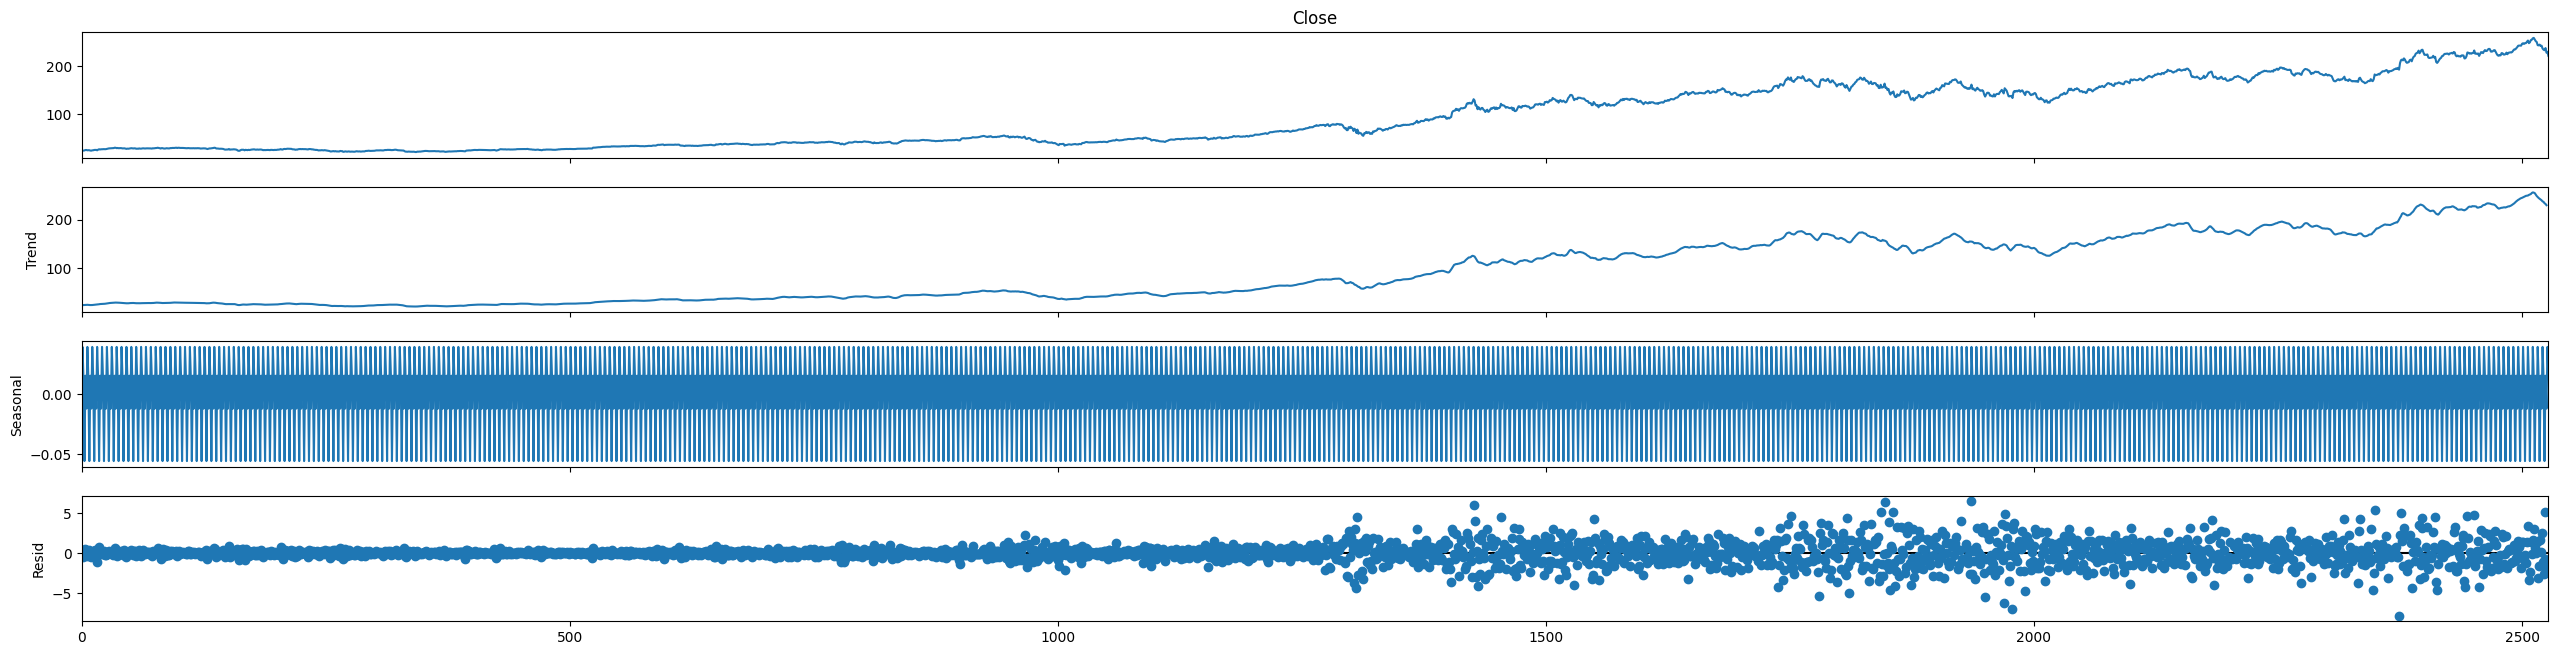

In [8]:
# Periode = 21
dec = sm.tsa.seasonal_decompose(df_aapl['Close'], period=5, model='additive').plot().set_size_inches(30,7)
plt.show()

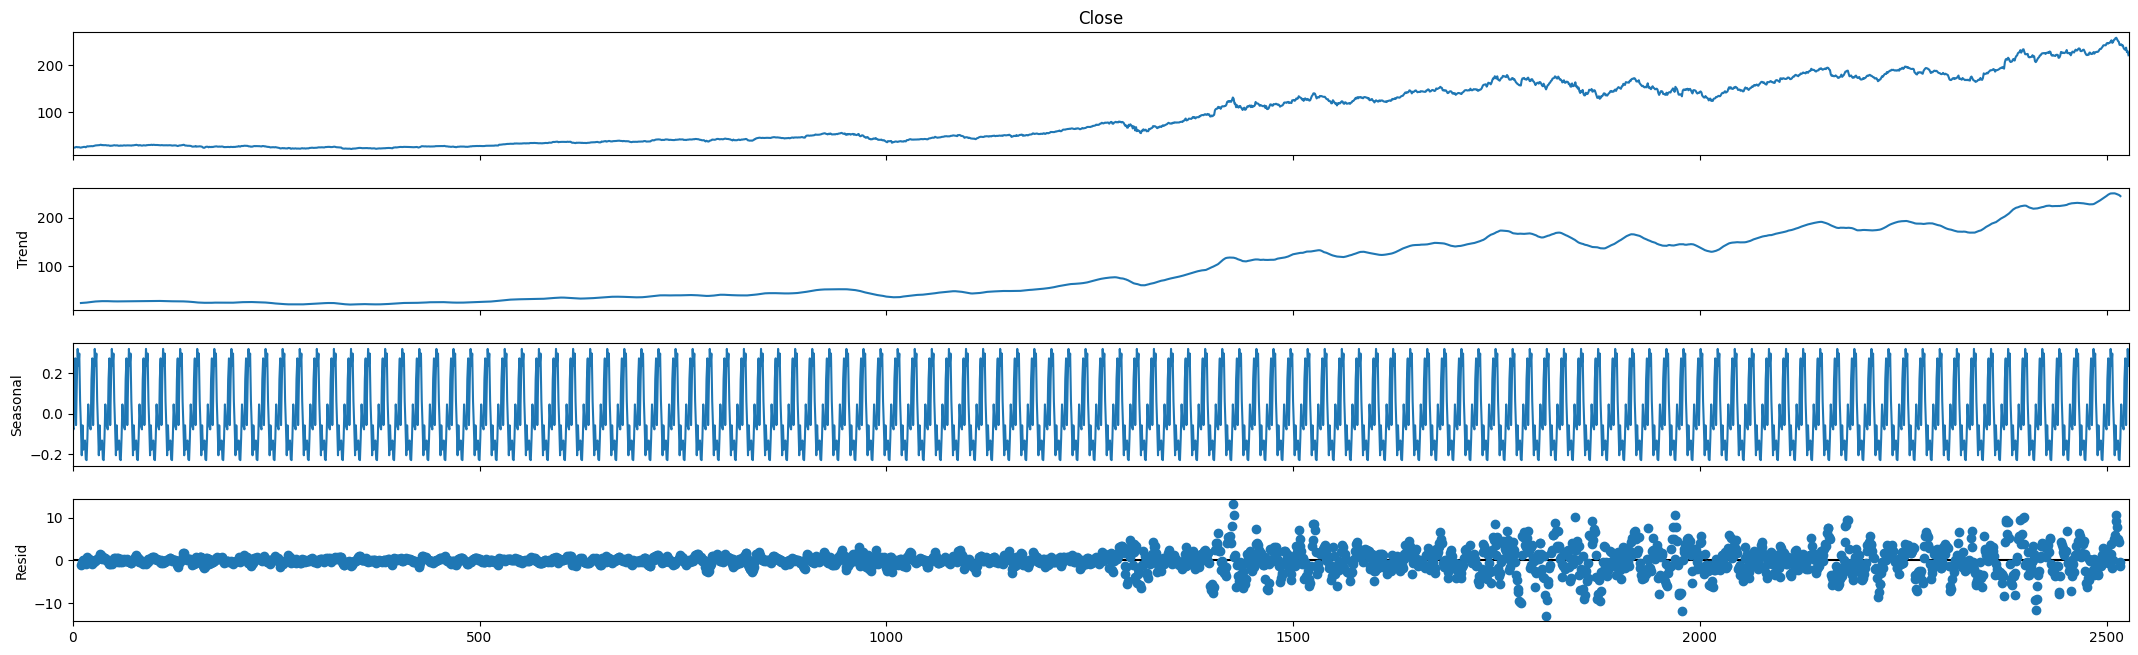

In [12]:
# Periode = 21
dec = sm.tsa.seasonal_decompose(df_aapl['Close'], period=21, model='additive').plot().set_size_inches(25,7)
plt.show()

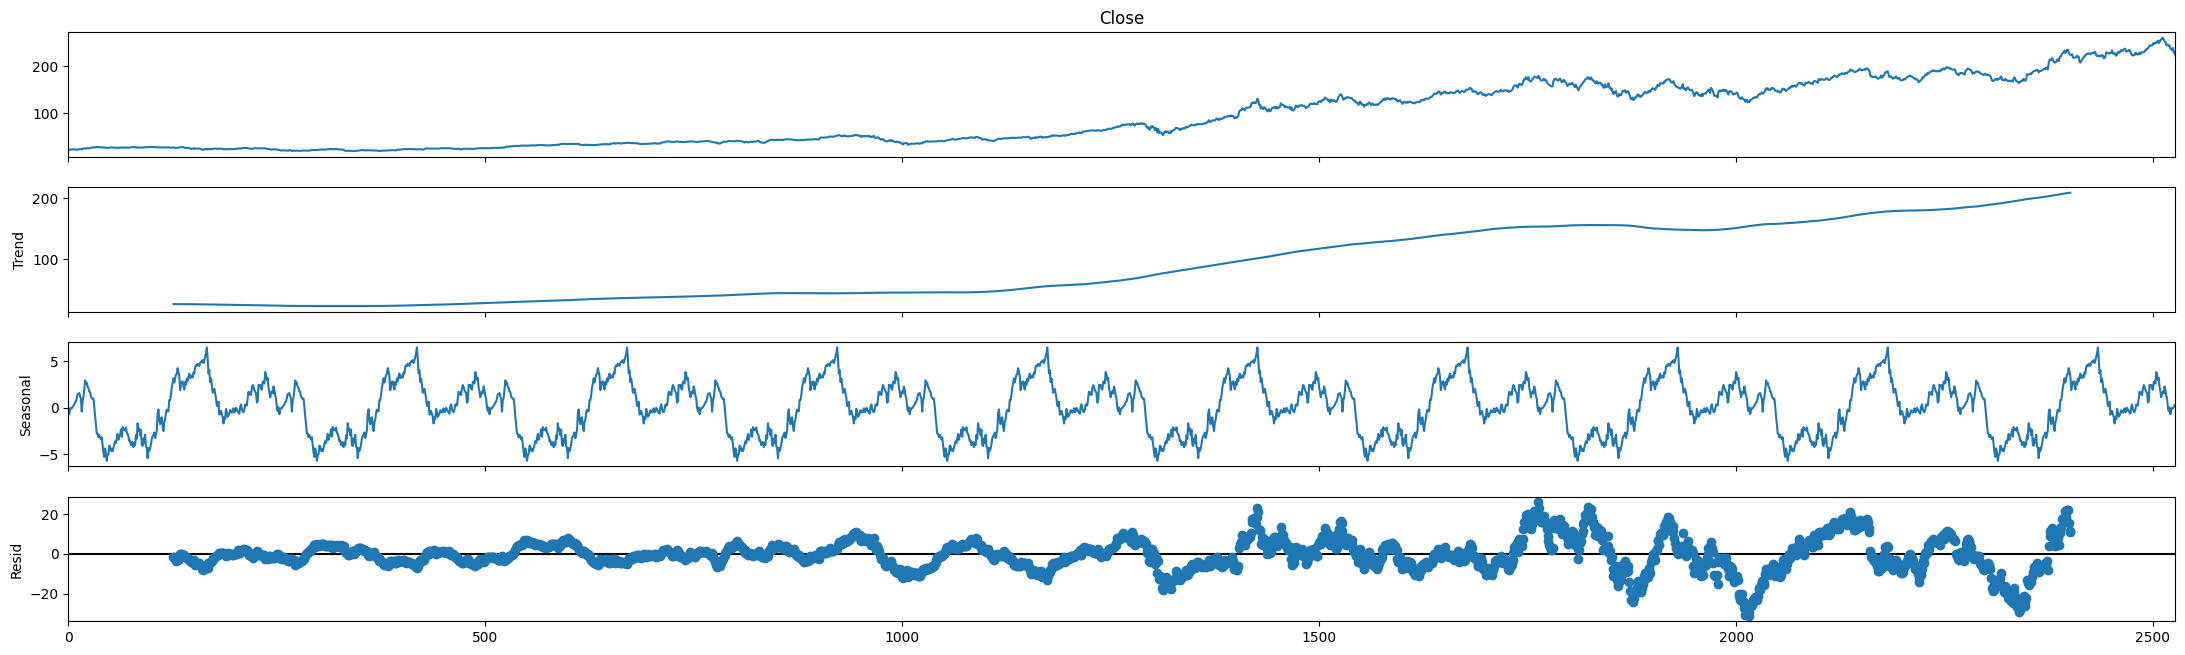

In [11]:
# Periode = 252
dec = sm.tsa.seasonal_decompose(df_aapl['Close'], period=252, model='additive').plot().set_size_inches(25,7)
plt.show()

### Multiplicative

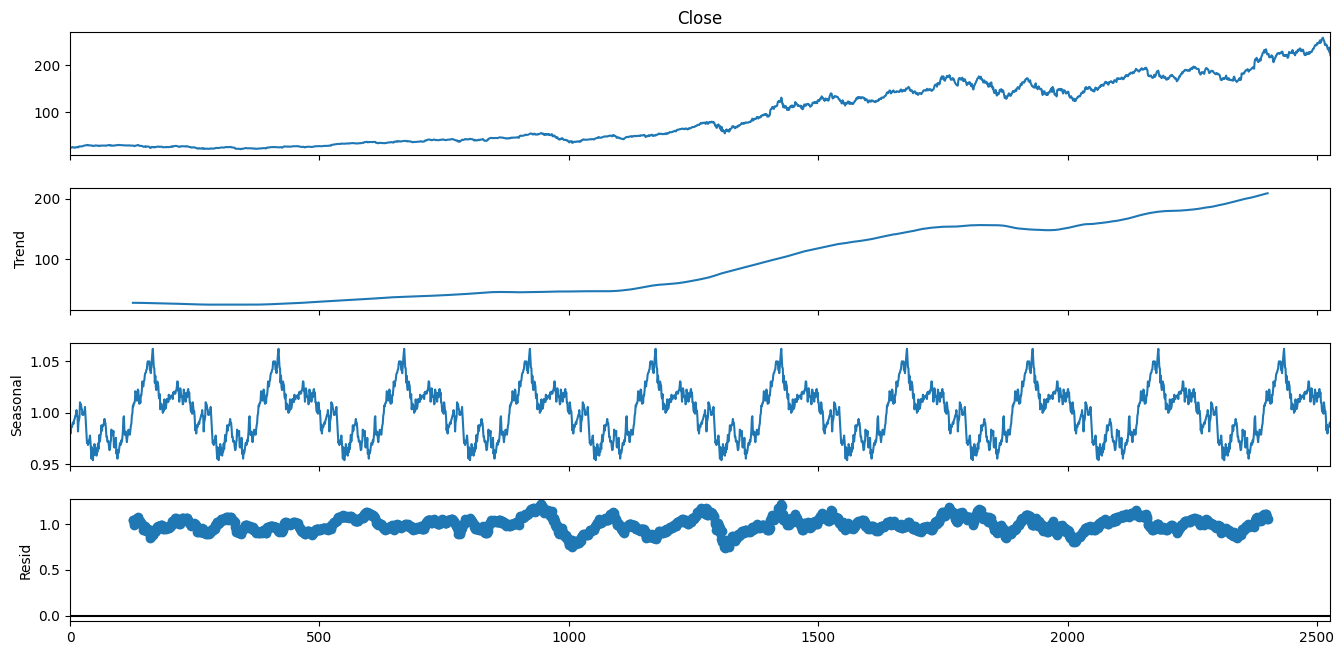

In [77]:
# Periode = 252 & model = multiplicative
dec = sm.tsa.seasonal_decompose(df_aapl['Close'], period=252, model='multiplicative').plot().set_size_inches(15,7)
plt.show()

# Modelling

In [78]:
# ---------- Model Configuration --------------
SINGLE_ATTENTION_VECTOR = False
INPUT_DIMS = 1
lstm_units = 64

In [79]:
def attention_3d_block(inputs):
    input_dim = int(inputs.shape[2])
    a = Dense(input_dim, activation='softmax')(inputs)
    if SINGLE_ATTENTION_VECTOR:
        a = Lambda(lambda x: K.mean(x, axis=1), name='dim_reduction')(a)
        a = RepeatVector(input_dim)(a)
    a_probs = Permute((1, 2), name='attention_vec')(a)
    output_attention_mul = Multiply()([inputs, a_probs])
    return output_attention_mul

def attention_3d_block2(inputs, single_attention_vector=False):
    time_steps = inputs.shape[1]
    input_dim = inputs.shape[2]
    a = Permute((2, 1))(inputs)
    a = Dense(time_steps, activation='softmax')(a)
    if single_attention_vector:
        a = Lambda(lambda x: K.mean(x, axis=1))(a)
        a = RepeatVector(input_dim)(a)
    a_probs = Permute((2, 1))(a)
    output_attention_mul = Multiply()([inputs, a_probs])
    return output_attention_mul

def NormalizeMult(data):
    data = np.array(data)
    normalize = np.zeros((data.shape[1], 2), dtype='float64')
    for i in range(data.shape[1]):
        col = data[:, i]
        listlow, listhigh = np.percentile(col, [0, 100])
        normalize[i, 0] = listlow
        normalize[i, 1] = listhigh
        delta = listhigh - listlow
        if delta != 0:
            data[:, i] = (data[:, i] - listlow) / delta
    return data, normalize

def FNormalizeMult(data, normalize):
    data = np.array(data)
    for i in range(data.shape[1]):
        listlow = normalize[i, 0]
        listhigh = normalize[i, 1]
        delta = listhigh - listlow
        if delta != 0:
            data[:, i] = data[:, i] * delta + listlow
    return data

def attention_model():
    inputs = Input(shape=(PERIOD, INPUT_DIMS))
    x = Conv1D(filters=64, kernel_size=1, activation='relu')(inputs)
    x = Dropout(0.3)(x)
    lstm_out = Bidirectional(LSTM(lstm_units, return_sequences=True))(x)
    lstm_out = Dropout(0.3)(lstm_out)
    attention_mul = attention_3d_block2(lstm_out)
    attention_mul = Flatten()(attention_mul)
    output = Dense(1, activation='linear')(attention_mul)
    model = Model(inputs=[inputs], outputs=output)
    return model

def rolling_forecast(model, dataset, look_back, input_dims):
    preds = []
    current_window = dataset[:look_back].copy()

    for i in range(len(dataset) - look_back):
        x_input = current_window.reshape(1, look_back, input_dims)
        pred = model.predict(x_input, verbose=0)
        preds.append(pred[0][0])

        # Update window: remove the earliest data and add prediction
        new_row = np.zeros((1, input_dims))
        new_row[0, 0] = pred[0][0]

        if input_dims > 1:
            new_row[0, 1:] = dataset[i + look_back, 1:]

        current_window = np.append(current_window[1:], new_row, axis=0)

    # Add NaN in front, so the length is the same
    pad = np.full(look_back, np.nan)
    final_preds = np.concatenate([pad, preds])
    final_preds = final_preds.reshape(-1, 1)

    return final_preds


In [80]:
model = attention_model()
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 252, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 252, 64)   │        128 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 252, 64)   │          0 │ conv1d_5[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_5     │ (None, 252, 128)  │     66,048 │ dropout_10[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 252, 128)  │          0 │ bidirectional_5[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute_10          │ (None, 128, 252)  │          0 │ dropout_11[0][0]  │
│ (Permute)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 128, 252)  │     63,756 │ permute_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute_11          │ (None, 252, 128)  │          0 │ dense_10[0][0]    │
│ (Permute)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_5          │ (None, 252, 128)  │          0 │ dropout_11[0][0], │
│ (Multiply)          │                   │            │ permute_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 32256)     │          0 │ multiply_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 1)         │     32,257 │ flatten_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 162,189 (633.55 KB)

 Trainable params: 162,189 (633.55 KB)

 Non-trainable params: 0 (0.00 B)

# Tuning

In [81]:
y_true = df_aapl[['Close']].values

## Using 5 Period

In [82]:
data = df_aapl[['Close']].values

In [83]:
PERIOD = 5
X_train, Y_train = create_dataset(data, PERIOD)

In [84]:
model = attention_model()
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.fit(X_train, Y_train, epochs=100, batch_size=32, validation_split=0.2)

Epoch 1/100


c:\Users\fadhil\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_66']. Received: the structure of inputs=*
  warnings.warn(


64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 7257.4849 - mae: 69.4460 - val_loss: 34052.6211 - val_mae: 182.4053
Epoch 2/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6011.6289 - mae: 59.4681 - val_loss: 31057.6836 - val_mae: 174.0037
Epoch 3/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4759.6680 - mae: 48.9914 - val_loss: 28254.6094 - val_mae: 165.7537
Epoch 4/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3977.5059 - mae: 42.4756 - val_loss: 25671.1387 - val_mae: 157.7682
Epoch 5/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3457.3530 - mae: 40.2890 - val_loss: 23491.5039 - val_mae: 150.7022
Epoch 6/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2927.1179 - mae: 36.3562 - val_loss: 21513.8828 - val_mae: 143.9915
Epoch 7/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2254.1772 - mae: 29.6125 - val_loss: 19661.2012 - val_mae: 137.4076
Epoch 8/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1838.6016 - mae: 25.6884 - val_loss: 18040.6016 - val_mae: 131.

In [85]:
score_test = model.evaluate(X_train, Y_train)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 174.7732 - mae: 7.8212


In [86]:
y_pred = model.predict(X_train)

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [87]:
print(f"Actual Data Length : {len(y_true)}")
print(f"Predict Data Length : {len(y_pred)}")

Actual Data Length : 2528
Predict Data Length : 2522


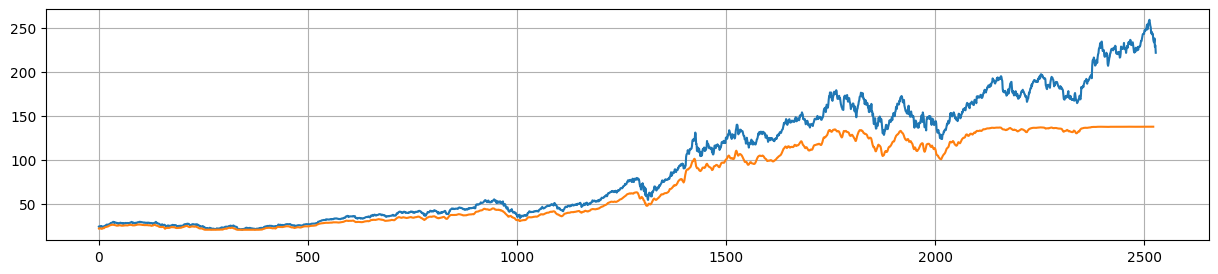

In [88]:
plt.figure(figsize=(15,3))
plt.plot(y_true, label='Actual')
plt.plot(y_pred, label='Predict')
plt.grid(True)

In [89]:
# Metrik Evaluation Calculation
full_y_pred = np.empty_like(y_true)
full_y_pred[:] = np.nan
full_y_pred[PERIOD:-1] = y_pred

mask = ~np.isnan(full_y_pred)
mae = mean_absolute_error(y_true[mask], full_y_pred[mask])
rmse = root_mean_squared_error(y_true[mask], full_y_pred[mask])
mape = mean_absolute_percentage_error(y_true[mask], full_y_pred[mask])

print(f"RMSE : {rmse} | MAE : {mae}, | MAPE : {mape}")

RMSE : 31.93417392642428 | MAE : 21.907532301712944, | MAPE : 0.1815943572839211


## Using 21 Period

In [90]:
PERIOD = 21
X_train, Y_train = create_dataset(data, PERIOD)

In [91]:
model = attention_model()
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.fit(X_train, Y_train, epochs=100, batch_size=32, validation_split=0.2)

Epoch 1/100


c:\Users\fadhil\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_77']. Received: the structure of inputs=*
  warnings.warn(


63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 7271.4653 - mae: 69.6488 - val_loss: 34118.0742 - val_mae: 182.6266
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5650.8789 - mae: 57.5540 - val_loss: 30042.9355 - val_mae: 171.1071
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 4585.4146 - mae: 47.3447 - val_loss: 26337.4062 - val_mae: 159.9128
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3386.3735 - mae: 39.4967 - val_loss: 22928.3867 - val_mae: 148.8727
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2931.5620 - mae: 37.5262 - val_loss: 20268.1523 - val_mae: 139.6526
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2184.4727 - mae: 29.0979 - val_loss: 17927.2715 - val_mae: 131.0037
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1763.2179 - mae: 25.5064 - val_loss: 15963.8574 - val_mae: 123.2824
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1334.5648 - mae: 21.5841 - val_loss: 14384.3711 - val_mae: 116.

In [92]:
score_test = model.evaluate(X_train, Y_train)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 217.7794 - mae: 9.6862


In [93]:
y_pred = model.predict(X_train)

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [94]:
print(f"Actual Data Length : {len(df_aapl['Close'])}")
print(f"Predict Data Length : {len(y_pred)}")

Actual Data Length : 2528
Predict Data Length : 2506


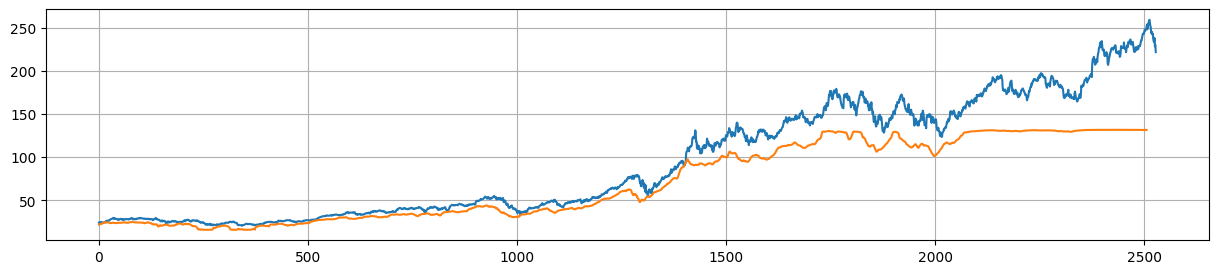

In [95]:
plt.figure(figsize=(15,3))
plt.plot(y_true, label='Actual')
plt.plot(y_pred, label='Predict')
plt.grid(True)

In [96]:
# Metrik Evaluation Calculation
full_y_pred = np.empty_like(y_true)
full_y_pred[:] = np.nan
full_y_pred[PERIOD:-1] = y_pred

mask = ~np.isnan(full_y_pred)
mae = mean_absolute_error(y_true[mask], full_y_pred[mask])
rmse = root_mean_squared_error(y_true[mask], full_y_pred[mask])
mape = mean_absolute_percentage_error(y_true[mask], full_y_pred[mask])

print(f"RMSE : {rmse} | MAE : {mae}, | MAPE : {mape}")

RMSE : 34.39932246386419 | MAE : 24.100945737584535, | MAPE : 0.2148631016446071


## Using 252 Period

In [97]:
PERIOD = 252
X_train, Y_train = create_dataset(data, PERIOD)

In [98]:
model = attention_model()
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.fit(X_train, Y_train, epochs=100, batch_size=32, validation_split=0.2)

Epoch 1/100


c:\Users\fadhil\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_88']. Received: the structure of inputs=*
  warnings.warn(


57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - loss: 7934.5293 - mae: 74.2172 - val_loss: 35514.0586 - val_mae: 186.7606
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - loss: 7138.1675 - mae: 67.1689 - val_loss: 31346.6035 - val_mae: 175.2479
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 5644.9351 - mae: 56.5342 - val_loss: 28238.4219 - val_mae: 166.1453
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - loss: 4677.8296 - mae: 49.2085 - val_loss: 25828.3105 - val_mae: 158.7266
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 4166.4009 - mae: 45.9725 - val_loss: 23848.2246 - val_mae: 152.3616
Epoch 6/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - loss: 3541.8818 - mae: 42.5072 - val_loss: 22187.1270 - val_mae: 146.8092
Epoch 7/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - loss: 3254.4285 - mae: 40.6238 - val_loss: 20611.3281 - val_mae: 141.3406
Epoch 8/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - loss: 2972.6118 - mae: 38.3299 - val_loss: 19112.5762 - val_m

In [99]:
score_test = model.evaluate(X_train, Y_train)

72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 165.4364 - mae: 7.5554


In [100]:
y_pred = model.predict(X_train)

72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step


In [101]:
print(f"Actual Data Length : {len(df_aapl['Close'])}")
print(f"Predict Data Length : {len(y_pred)}")

Actual Data Length : 2528
Predict Data Length : 2275


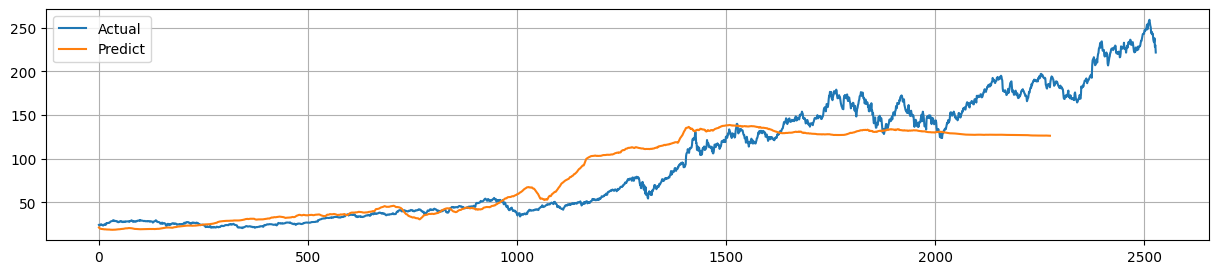

In [102]:
plt.figure(figsize=(15,3))
plt.plot(y_true, label='Actual')
plt.plot(y_pred, label='Predict')
plt.grid(True)
plt.legend()

In [103]:
# Metrik Evaluation Calculation
full_y_pred = np.empty_like(y_true)
full_y_pred[:] = np.nan
full_y_pred[PERIOD:-1] = y_pred

mask = ~np.isnan(full_y_pred)
mae = mean_absolute_error(y_true[mask], full_y_pred[mask])
rmse = root_mean_squared_error(y_true[mask], full_y_pred[mask])
mape = mean_absolute_percentage_error(y_true[mask], full_y_pred[mask])

print(f"RMSE : {rmse} | MAE : {mae}, | MAPE : {mape}")

RMSE : 33.924020148189065 | MAE : 20.966105036473536, | MAPE : 0.16301034758141772
